# **ESZA019 - Visão Computacional**
***## Laboratório 7 - Introdução às redes CNN***
*Convolutional Neural Networks* para Reconhecimento em Imagens

# ***integrantes***


* Eduarda Alexandre de Salles

* Gustravo Souza

* Paloma Santana



Neste roteiro, para fins didáticos, utilizaremos o **Google Colab Interativo** o framework  **TensorFlow / Keras**, projetado para alunos de graduação em Engenharia e Computação.

Fundamentos: **Szeliski, R. *Computer Vision: Algorithms and Applications (2nd Ed.)*, Capítulo 5.4.**

Aplicação prática em robótica móvel/manipulação: integração de visão em tempo real usando a webcam.

O relatório da equipe deverá ser feito no **Jupyter notebook**.

---

## 🎯 Objetivos de Aprendizagem
1. Compreender a transição dos **Filtros Espaciais Clássicos** (Sobel, Gaussiano) para os **Filtros Aprendidos (CNN)**.
2. Construir e treinar uma CNN compacta em **TensorFlow/Keras** para reconhecimento de objetos.
3. Inspecionar os *Feature Maps* das camadas convolucionais para "abrir a caixa-preta" da rede.
4. Testar a rede em tempo real conectando um sensor de visão (Webcam) diretamente no Colab.

---

## 📚 Conexão Teórica: Szeliski Cap. 5.4
No processamento de imagem tradicional, definimos manualmente os pesos do filtro. Por exemplo, para detectar bordas verticais para navegação de um robô, usamos um filtro Sobel $3 \times 3$:

$$H = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$

Como visto em **Szeliski 5.4**, uma **Camada Convolucional** aplica múltiplos kernels $K \times K \times C$ em paralelo, mas com uma diferença fundamental: **os valores do kernel são parâmetros ajustáveis $(\theta)$ aprendidos via Gradiente Descendente e Backpropagation**.


In [ ]:
## IMPORTANTE: Antes de iniciar, configure no menu do Colab:
# [Edit] -> [Notebook settings] -> ()T4 GPU ok

In [ ]:
## 1. Importação de Bibliotecas
# Importação das bibliotecas essenciais
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print(f"Versão do TensorFlow: {tf.__version__}")
# Verificar se a GPU está ativa (fundamental para aceleração em robótica)
gpu_available = len(tf.config.list_physical_devices('GPU')) > 0
print(f"Aceleração por GPU Ativa: {gpu_available}")

Versão do TensorFlow: 2.20.0
Aceleração por GPU Ativa: True


# ***Introdução***

  Este relatório documenta os experimentos realizados no Laboratório 7 da disciplina ESZA019 - Visão Computacional, cujo objetivo central é introduzir os conceitos fundamentais de Redes Neurais Convolucionais (CNNs) aplicados ao reconhecimento de imagens, com foco em aplicações de percepção robótica.

  O trabalho parte da comparação entre técnicas clássicas de processamento de imagem, como o filtro de Sobel para detecção de bordas, e o paradigma de aprendizado profundo, no qual os próprios filtros de convolução são aprendidos automaticamente a partir dos dados durante o treinamento, em vez de serem definidos manualmente. Essa transição ilustra uma mudança fundamental na forma como sistemas de visão computacional passaram a lidar com a complexidade e a variabilidade de ambientes reais, especialmente relevante para robôs móveis que precisam operar em condições não controladas.

  Ao longo do laboratório, foi construída, treinada e avaliada uma rede convolucional compacta utilizando o dataset CIFAR-10, capaz de classificar objetos em dez categorias, incluindo veículos como automóveis, caminhões, aviões e navios — categorias diretamente relevantes para cenários de navegação autônoma. Além da etapa de treinamento e avaliação quantitativa por meio de métricas como acurácia, perda e matriz de confusão, o relatório também investiga a interpretabilidade da rede através da visualização dos mapas de características aprendidos pelas camadas convolucionais, e testa o modelo em condições reais de captura via webcam, expondo desafios práticos como o fenômeno de domain shift, a latência do pipeline de inferência e a necessidade de mecanismos de segurança para sistemas de decisão automatizada.

  Por fim, são discutidas melhorias voltadas à robustez do sistema, como o uso de aumento de dados (data augmentation) para tornar o modelo mais resiliente a variações de iluminação e orientação, e a implementação de um filtro de rejeição por confiança, que visa prevenir decisões equivocadas do robô diante de classificações incertas — um aspecto crítico quando se considera a aplicação desse tipo de sistema em contextos de segurança física e tomada de decisão autônoma.

## Parte 1. Filtro Manual (Sobel) vs. Conceito de Kernel Aprendido
Antes de construir a rede **CNN**, aplicar um **filtro de convolução** manual em uma imagem de teste para visualizar a **extração de características**.


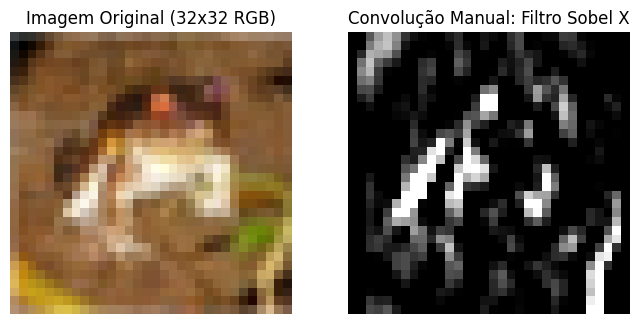

In [ ]:
## 2. Convolução Clássica com OpenCV/NumPy
# Carregando uma imagem de exemplo do dataset CIFAR-10
(x_train_raw, y_train_raw), _ = tf.keras.datasets.cifar10.load_data()
sample_img = x_train_raw[0] # Imagem 32x32 RGB

# Converter para escala de cinza
gray_img = cv2.cvtColor(sample_img, cv2.COLOR_RGB2GRAY)

# Definindo o Filtro Sobel X (Bordas Verticais - Szeliski 5.4.1)
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

# Aplicando a Convolução
edges_x = cv2.filter2D(gray_img, -1, sobel_x)

# Visualização
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Imagem Original (32x32 RGB)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges_x, cmap='gray')
plt.title("Convolução Manual: Filtro Sobel X")
plt.axis('off')
plt.show()

**Elabore:** Numa nova célula abaixo, código para gerar mais exemplos desta filtragem, sendo pelo menos três imagens diferentes do dataset CIFAR-10, por aluno da equipe. Dica: modifique o índice no comando: sample_img = x_train_raw[0]

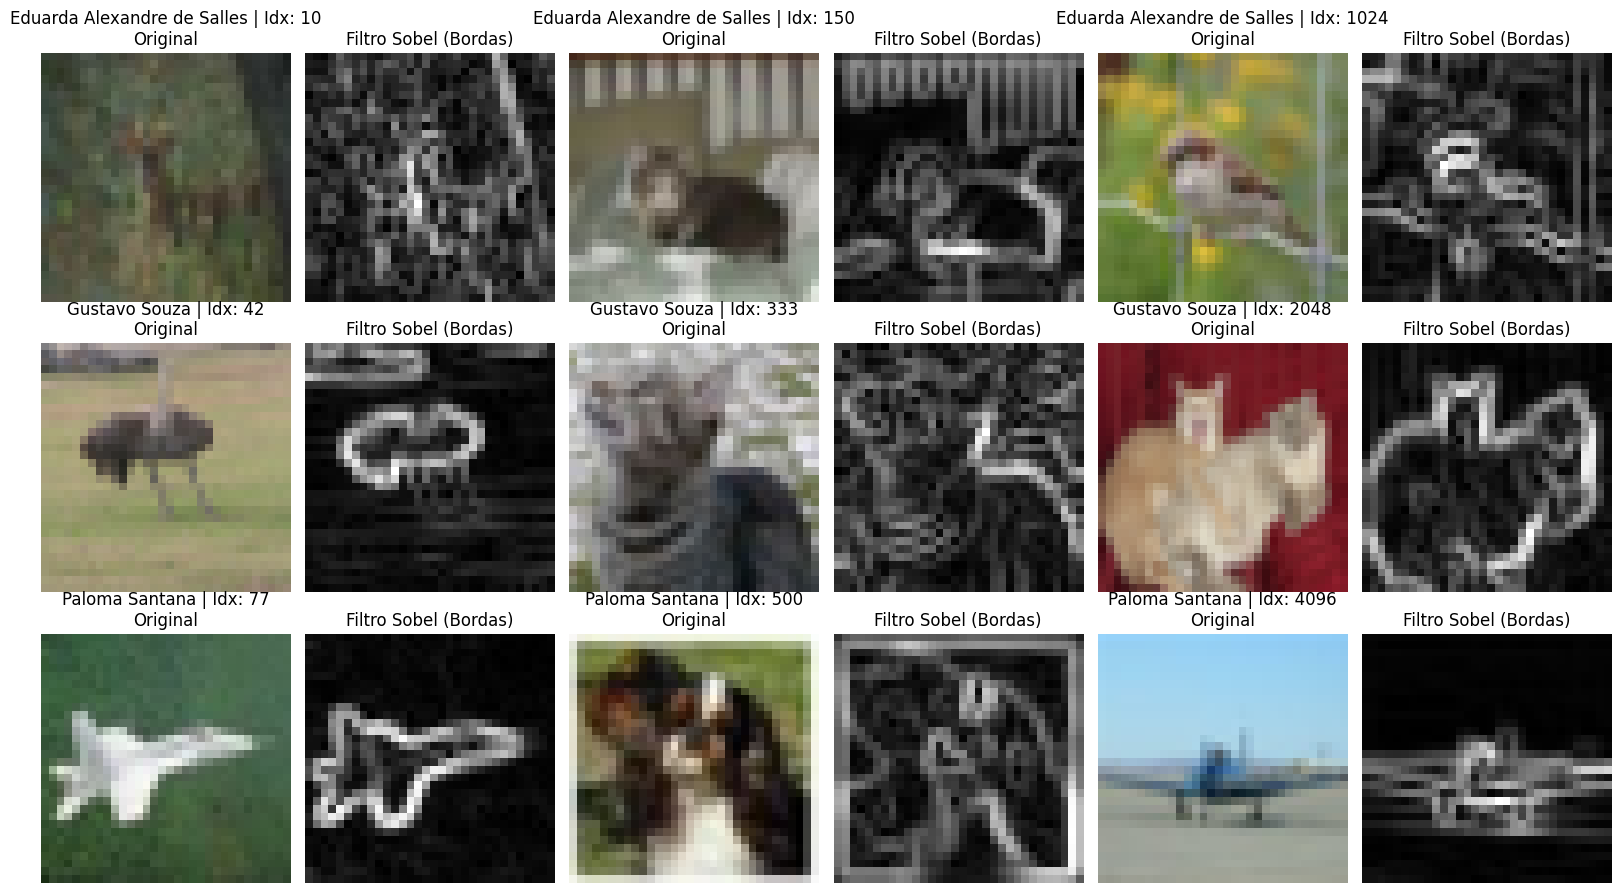

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve2d

# Dicionário com os índices das imagens para cada aluno (3 por aluno)
batch_equipe = {
    "Eduarda Alexandre de Salles": [10, 150, 1024],
    "Gustavo Souza": [42, 333, 2048],
    "Paloma Santana": [77, 500, 4096]
}

# Definição manual dos kernels (filtros) de Sobel para detectar bordas
sobel_x = np.array([[-1,  0,  1],
                    [-2,  0,  2],
                    [-1,  0,  1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

num_alunos = len(batch_equipe)
fig, axes = plt.subplots(nrows=num_alunos, ncols=6, figsize=(16, 3 * num_alunos))

for i, (aluno, indices) in enumerate(batch_equipe.items()):
    for j, idx in enumerate(indices):

        sample_img = x_train_raw[idx]

        # 1. Converte imagem RGB para tons de cinza para aplicar o filtro
        gray_img = np.dot(sample_img[...,:3], [0.2989, 0.5870, 0.1140])

        # 2. Aplica a convolução (extração de características) usando scipy
        grad_x = convolve2d(gray_img, sobel_x, mode='same', boundary='symm')
        grad_y = convolve2d(gray_img, sobel_y, mode='same', boundary='symm')

        # 3. Combina as bordas horizontais e verticais calculando a magnitude
        img_filtrada = np.hypot(grad_x, grad_y)

        # 4. Normaliza os valores para a escala 0-255 (padrão de imagem)
        img_filtrada = (img_filtrada / img_filtrada.max()) * 255.0
        img_filtrada = img_filtrada.astype(np.uint8)

        # --- Plotagem da Imagem Original ---
        col_orig = j * 2
        ax_orig = axes[i, col_orig]
        ax_orig.imshow(sample_img)
        ax_orig.set_title(f"{aluno} | Idx: {idx}\nOriginal")
        ax_orig.axis('off')

        # --- Plotagem da Imagem Filtrada (Mapa de Características) ---
        col_filt = j * 2 + 1
        ax_filt = axes[i, col_filt]
        ax_filt.imshow(img_filtrada, cmap='gray')
        ax_filt.set_title("Filtro Sobel (Bordas)")
        ax_filt.axis('off')

plt.tight_layout()
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre a diferença entre processamento de imagem clássico e aprendizado profundo:

* **1:** Foi aplicado o filtro clássico de Sobel para detectar bordas verticais. Qual é a principal limitação matemática e prática de utilizar apenas filtros codificados manualmente (como Sobel ou Canny) no sistema de visão de um robô que navega em ambientes externos?

    R: Limitação Matemática:
    A restrição fundamental dos filtros clássicos é que eles utilizam kernels estáticos e inflexíveis. Uma matriz de Sobel aplica sempre a mesma operação linear na imagem, independentemente do que está sendo analisado. Matematicamente, a operação não possui parâmetros ajustáveis e não consegue se adaptar a transformações essenciais, como mudanças de escala (objetos próximos vs. distantes), rotações ou variações não-lineares nos dados da imagem.

    Limitação Prática:
    Para um robô navegando em um ambiente externo, as condições do mundo real são caóticas e cheias de ruído (variações de iluminação, chuva, texturas complexas do asfalto ou vegetação). Um filtro manual de bordas é "cego" para o contexto semântico. Ele reage puramente ao gradiente de intensidade dos pixels. Na prática, o algoritmo vai detectar a borda de uma sombra no chão com a mesma força que detecta o meio-fio ou um obstáculo real, o que tornaria a navegação do robô impossível por excesso de falsos positivos e ruído geométrico.

* **2:** Com base no capítulo 5.4 de Szeliski, explique com suas palavras: o que exatamente a rede neural está "aprendendo" durante a fase de treinamento em uma camada convolucional que substitui a necessidade de criarmos o filtro manualmente?

    R: Na camada convolucional, a rede neural aprende os próprios valores numéricos (pesos) das matrizes de convolução, eliminando a necessidade de design manual. A partir de valores iniciais aleatórios, os kernels são ajustados iterativamente através da retropropagação para minimizar o erro das previsões. Através dessa otimização guiada por dados, as camadas iniciais convergem naturalmente para detectores de bordas e contrastes, enquanto as camadas mais profundas combinam esses filtros básicos para identificar texturas e geometrias complexas, alcançando um nível de abstração que seria inviável programar matematicamente.


## Parte 2: Pipeline de Dados de Percepção

### . Preparação do Dataset (CIFAR-10)
Utilizaremos o dataset CIFAR-10 contendo 10 classes (incluindo veículos como *carro*, *caminhão*, *avião* e *navio*, relevantes para robótica móvel).

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1642s 10us/step


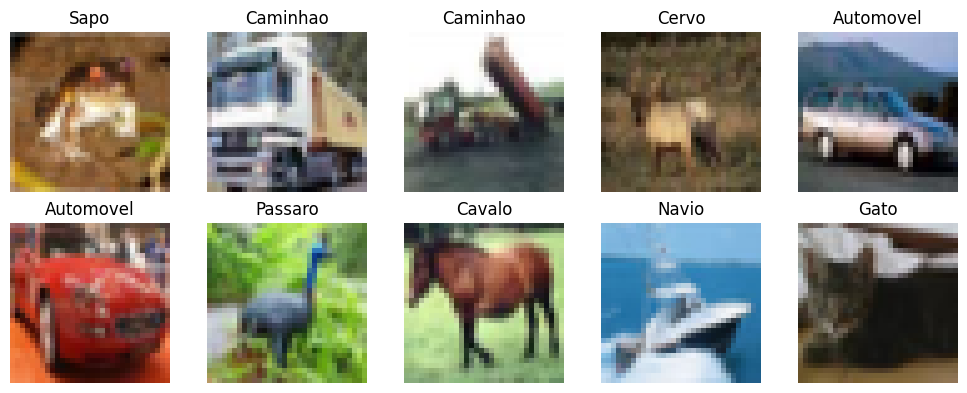

In [ ]:
## 3. Download e Pré-processamento
# Carregar CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalização dos píxeis para o intervalo [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

class_names = ['Aviao', 'Automovel', 'Passaro', 'Gato', 'Cervo',
               'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhao']

# Visualizar amostras
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre  a preparação dos dados sensoriais e representação matricial:

* **3:** Na preparação do dataset, os pixels foram divididos por $255.0$. Quanto à otimização matemática (cálculo de gradientes), por que essa normalização é necessária para o treinamento da rede neural do robô?

  R: A normalização transforma os valores dos pixels, que originalmente variam de 0 a 255, para o intervalo 0 a 1. Isso é importante porque facilita os cálculos realizados durante o treinamento da rede neural. Quando os valores de entrada são muito grandes, os gradientes podem ficar instáveis, fazendo com que o treinamento seja mais lento ou apresente dificuldades para convergir. Com os dados normalizados, as atualizações dos pesos acontecem de forma mais equilibrada, tornando o processo de otimização mais eficiente e permitindo que a rede aprenda mais rapidamente e com maior estabilidade.

* **4:** O dataset CIFAR-10 possui apenas imagens de ($32 \times 32$ pixels). Se o robô utilizar câmera 4K ($3840 \times 2160$ pixels), o que aconteceria com a quantidade de parâmetros da primeira camada densa (*Flatten* seguida de *Dense*) e como isso impactaria o hardware embarcado? (Apresente exemplos)

  R: Se o robô utilizasse uma câmera 4K (3840 × 2160), a quantidade de dados de entrada seria muito maior do que no CIFAR-10, que utiliza imagens de apenas 32 × 32 pixels. Enquanto uma imagem do CIFAR-10 possui 3.072 valores (32 × 32 × 3), uma imagem 4K possui 24.883.200 valores (3840 × 2160 × 3). Se fosse utilizada uma camada Flatten seguida de uma Dense, todos esses valores seriam conectados aos neurônios da camada densa, aumentando drasticamente a quantidade de parâmetros da rede. Por exemplo, uma camada densa com 128 neurônios teria cerca de 393 mil parâmetros usando imagens do CIFAR-10, mas aproximadamente 3,18 bilhões de parâmetros com imagens 4K. Isso tornaria o treinamento e a execução muito mais lentos, além de exigir uma grande quantidade de memória e processamento, o que seria inviável para um hardware embarcado, como um Raspberry Pi ou um robô móvel. Por esse motivo, em aplicações reais é comum reduzir a resolução das imagens e utilizar camadas convolucionais e de pooling, que conseguem extrair as características mais importantes sem aumentar excessivamente o número de parâmetros da rede.

## Parte 3: Construção da CNN em Keras

### . Arquitetura da Rede Convolucional (RobotVisionNet)
A arquitetura segue o padrão clássico descrito por Szeliski:
1. **Camadas Convolucionais (`Conv2D`):** Extração de mapas de características.
2. **Camadas de Max Pooling (`MaxPooling2D`):** Redução dimensional e garantia de **invariância a pequenas translações** do objeto no campo de visão da câmera.
3. **Camadas Densas (`Dense`):** Tomada de decisão/classificação final.


In [ ]:
## 4. Definição do Modelo Keras

def build_robot_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        # Bloco Convolucional 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape, name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),

        # Bloco Convolucional 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),

        # Classificador (Fully Connected)
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

model = build_robot_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

**Analise os resultados e responda com suas próprias palavras:** sobre a arquitetura da rede e suas propriedades espaciais.

* **5:** Na arquitetura construída, por que as camadas convolucionais (Conv2D) são posicionadas no início do modelo e as camadas densas (Dense) apenas no final, e não o contrário? Qual o papel funcional de cada um desses blocos metodológicos?

  R: As camadas convolucionais (Conv2D) são colocadas no início da rede porque são responsáveis por extrair as características mais importantes da imagem. Primeiro, elas identificam padrões simples, como bordas e linhas, e conforme a imagem passa pelas próximas camadas, conseguem reconhecer padrões mais complexos, como formas e partes dos objetos. Já as camadas de MaxPooling reduzem o tamanho dos mapas de características, diminuindo a quantidade de cálculos e tornando a rede menos sensível a pequenas mudanças na posição do objeto.

  Depois que essas características são extraídas, a camada Flatten transforma os mapas em um vetor, permitindo que as camadas Dense façam a classificação. As camadas densas combinam todas as informações aprendidas anteriormente para decidir a qual classe a imagem pertence, enquanto a última camada, com ativação softmax, retorna a probabilidade de cada classe.

  Essa organização faz sentido porque, se as camadas densas fossem colocadas no início, a rede perderia as informações espaciais da imagem, tratando apenas os valores dos pixels sem considerar a relação entre eles. Além disso, haveria um aumento muito grande no número de parâmetros, tornando o treinamento menos eficiente. Por isso, a arquitetura das CNNs segue essa sequência: primeiro extrair características com as camadas convolucionais e, no final, utilizar as camadas densas para realizar a classificação.

## Parte 4: Compilação e Treinamento

### . Treinamento da Rede
Definimos a função de perda (`sparse_categorical_crossentropy`) e o otimizador (`Adam`).


In [ ]:
## 5. Execução do Treinamento

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Treinamento por 10 épocas
history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_data=(x_test, y_test),
                    batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.4404 - loss: 1.5465 - val_accuracy: 0.5733 - val_loss: 1.2061
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5734 - loss: 1.2015 - val_accuracy: 0.6317 - val_loss: 1.0725
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6298 - loss: 1.0530 - val_accuracy: 0.6592 - val_loss: 0.9752
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6585 - loss: 0.9636 - val_accuracy: 0.6669 - val_loss: 0.9433
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6881 - loss: 0.8872 - val_accuracy: 0.6949 - val_loss: 0.8747
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7081 - loss: 0.8279 - val_accuracy: 0.7054 - val_loss: 0.8525
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7280 - loss: 0.7743 - val_accuracy: 0.7118 - val_loss: 0.8416
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7412 - loss: 0.7303 - val_accuracy: 0

**Analise os resultados e responda com suas próprias palavras:** sobre a dinâmica do aprendizado, as métricas e a função de custo.

* **6:** Durante as 10 épocas de treinamento, o gráfico gerado mostra os valores da *Loss* (Perda). Defina o que a função de perda mede. Se o gráfico demonstrar que a perda de treinamento continua caindo rumo a zero, mas a perda de validação estaciona ou começa a subir, qual fenômeno está ocorrendo e como ele afetaria o robô na prática?

  R: A função de perda (loss) mede o quanto as previsões feitas pelo modelo estão diferentes dos valores corretos. Quanto menor for esse valor, significa que a rede está cometendo menos erros durante o treinamento. Neste caso, foi utilizada a sparse_categorical_crossentropy, que é indicada para problemas de classificação com várias classes, onde cada imagem pertence a apenas uma categoria.

  Se a perda de treinamento continua diminuindo, mas a perda de validação para de diminuir ou começa a aumentar, isso indica que o modelo está sofrendo overfitting. Ou seja, ele está aprendendo muito bem os exemplos do conjunto de treinamento, mas não consegue generalizar esse conhecimento para dados novos.

  Na prática, isso afetaria o robô porque ele teria um bom desempenho apenas com imagens parecidas com as usadas no treinamento. Quando encontrasse objetos em situações diferentes, com outra iluminação, posição ou fundo, a chance de cometer erros na classificação seria maior, reduzindo a confiabilidade do sistema. Por isso, o objetivo é encontrar um modelo que tenha um bom desempenho tanto no treinamento quanto na validação, mostrando que ele consegue generalizar para novos dados.


## Parte 5: Diagnóstico e Matriz de Confusão

### . Avaliação do Desempenho
Em Engenharia Robótica, é necessário identificar falhas específicas: se o robô confundir um *automóvel* com um *caminhão*, o impacto na navegação pode ser tolerável; se confundir um *pedestre/animal* com um *objeto inanimado*, o erro é crítico.

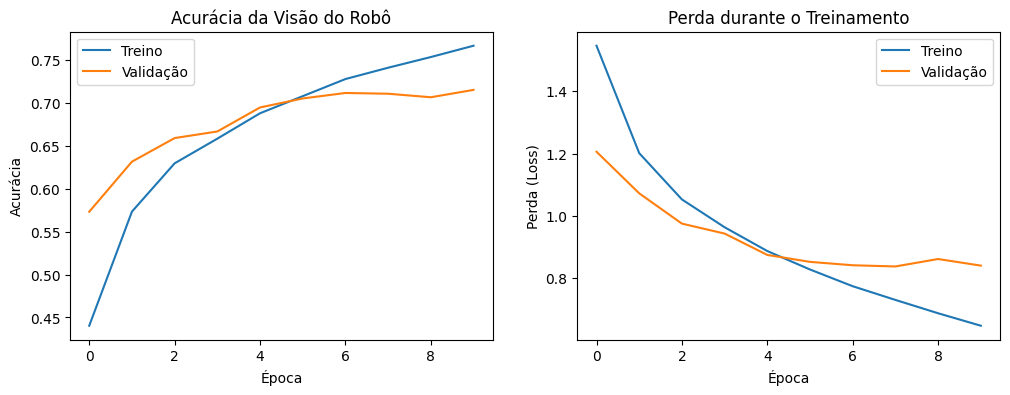

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


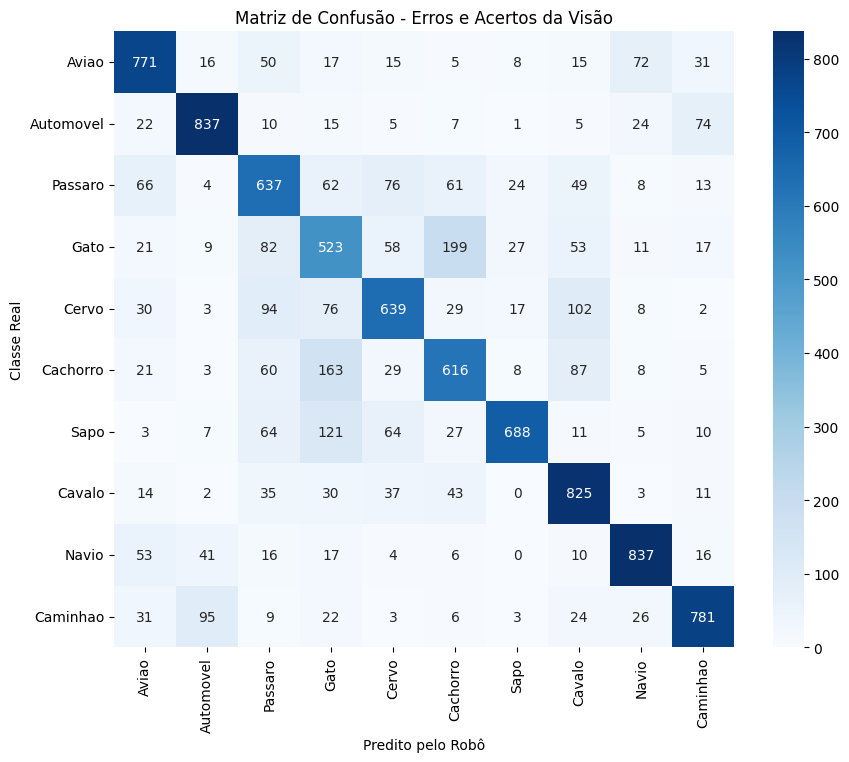

In [ ]:
## 6. Gráficos e Matriz de Confusão

# Curvas de Aprendizado
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia da Visão do Robô')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Perda (Loss)')
plt.title('Perda durante o Treinamento')
plt.legend()
plt.show()

# Matriz de Confusão
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predito pelo Robô')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Erros e Acertos da Visão')
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre as métricas de forma crítica com foco na tomada de decisão do robô.

* **7:** Observe a Matriz de Confusão gerada pelo seu modelo. Quais foram as duas classes com o maior índice de falsos positivos. Do ponto de vista da semântica das imagens, por que a rede cometeu esse erro específico?

  R: Observando a matriz de confusão, as duas maiores ocorrências de falsos positivos estão relacionadas às classes Gato e Cachorro, que foram confundidas com bastante frequência entre si (225 gatos classificados como cachorros e 131 cachorros classificados como gatos). Também há uma confusão relevante entre Automóvel e Caminhão (92 caminhões classificados como automóveis e 86 automóveis classificados como caminhões).

  Esses erros acontecem porque essas classes possuem características visuais parecidas. No caso de gatos e cachorros, ambos apresentam formatos, texturas e cores semelhantes, principalmente quando aparecem em poses ou ângulos parecidos. Já automóveis e caminhões compartilham elementos como rodas, carroceria e formato geral de veículos, o que pode dificultar a distinção quando a imagem não mostra detalhes suficientes.

* **8:** Se hipoteticamente este modelo é implantado no sistema de frenagem de emergência de um robô de patrulha. Errar a classe "Automóvel" classificando-a como "Caminhão" tem o mesmo peso de gravidade que classificar um "Cachorro" como um "Caminhão"? Como a matriz de confusão nos ajuda a auditar a segurança do robô?

  R: Os erros não possuem o mesmo nível de gravidade. Se o robô confundir um automóvel com um caminhão, ele ainda identifica que existe um veículo à frente e pode tomar uma decisão de segurança, como reduzir a velocidade ou frear. Embora a classificação esteja incorreta, o risco tende a ser menor.

  Por outro lado, classificar um cachorro como um caminhão é um erro muito mais crítico. Nesse caso, o robô pode interpretar incorretamente o tipo de obstáculo e tomar uma decisão inadequada, colocando em risco a segurança do animal ou até de pessoas próximas.

  A matriz de confusão é importante porque não mostra apenas a acurácia total do modelo, mas também quais tipos de erros estão sendo cometidos. Isso permite identificar quais confusões são mais perigosas em uma aplicação real e avaliar se o modelo é seguro o suficiente para ser utilizado em sistemas críticos, como um sistema de frenagem de emergência. Dessa forma, é possível direcionar melhorias no treinamento para reduzir justamente os erros que oferecem maior risco.

## Parte 6: Visualizando as Características Aprendidas (Szeliski 5.4.6)

### . Visualização dos *Feature Maps*
**Objetivo:** Extrair as saídas da primeira camada convolucional (`conv_1`) após o treinamento para comprovar que a rede aprendeu automaticamente detectores de bordas, orientação e contraste!

Atenção: os mapas de características (*feature_maps*) representam as ativações dos diferentes filtros (ou kernels) aprendidos pela primeira camada convolucional (conv_1) da rede. Estes elementos serão progressivamente combinados e refinados nas camadas mais profundas para formar representações complexas que permitirão à rede distinguir entre as dez classes diferentes do dataset CIFAR-10.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


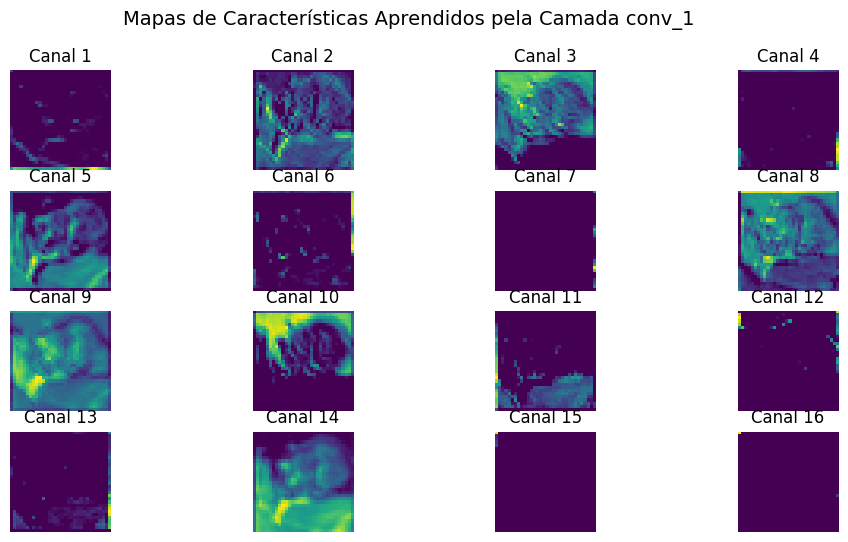

In [ ]:
## 7. Inspeção de Ativações da Camada Convolucional

model.build(input_shape=(None, 32, 32, 3))
# Forçar o modelo a ser 'chamado' para garantir que seu grafo esteja construído
dummy_input = tf.zeros((1, 32, 32, 3))
_ = model(dummy_input)

# Criar modelo intermediário para extrair a saída da camada 'conv_1'
activation_model = tf.keras.Model(inputs=model.layers[0].input, outputs=model.get_layer('conv_1').output)

# Obter ativações para uma imagem de teste
sample_input = np.expand_dims(x_test[0], axis=0);
feature_maps = activation_model.predict(sample_input) # Formato: (1, 32, 32, 32)

plt.figure(figsize=(12, 6))
for i in range(16): # Exibir os primeiros 16 canais aprendidos
    plt.subplot(4, 4, i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Canal {i+1}')
plt.suptitle('Mapas de Características Aprendidos pela Camada conv_1', fontsize=14)
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre a interpretabilidade de redes neurais.

* **9:** Nas saídas (ativações) da camada conv_1, alguns canais destacam bordas enquanto outros destacam texturas. Caso visualizasse os *Feature Maps* da última camada convolucional antes do classificador, seria possível encontrar características mais simples (como linhas e pontos) ou mais complexas (como formatos abstratos do objeto inteiro)? Explique o motivo anatômico da CNN.

  R: Se fossem visualizados os Feature Maps da última camada convolucional, o esperado seria encontrar características mais complexas, e não apenas linhas, bordas ou pontos. Isso acontece porque, em uma CNN, cada camada utiliza as informações extraídas pela camada anterior para formar representações cada vez mais elaboradas.

  Nas primeiras camadas, como a conv_1, a rede aprende características básicas, como bordas, contrastes, orientações e pequenas texturas. Já nas camadas intermediárias, essas informações são combinadas para identificar padrões maiores, como curvas, cantos e partes de objetos. Por fim, nas últimas camadas convolucionais, a rede consegue reconhecer características mais abstratas, como o formato de rodas, asas, focinhos ou até partes que representam um objeto inteiro.

  Esse comportamento acontece por conta da arquitetura hierárquica da CNN. Cada camada aumenta o campo receptivo e combina os padrões detectados anteriormente, permitindo que a rede passe de informações simples para representações mais complexas. Por isso, as últimas camadas são as que fornecem as características mais úteis para que o classificador consiga diferenciar corretamente as classes do conjunto de dados.

## Parte 7: Aplicação Prática com Webcam ao Vivo

### . Teste de Percepção em Tempo Real via Webcam
Agora conectar a câmera do seu computador! Mostrar objetos reais (como brinquedos de carros, miniaturas ou imagens no celular) para testar a predição da sua rede neural em tempo real.

Aguardando interação com a câmera...


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


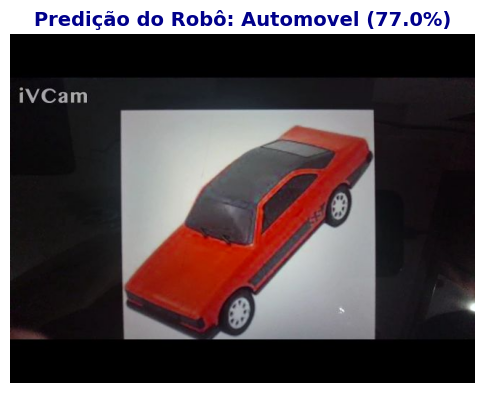

In [ ]:
## 8. Bridge JavaScript/Python para Captura de Webcam no Colab

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import io
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função JavaScript para acessar a webcam e capturar um frame
def capture_webcam_frame():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const capture = document.createElement('button');

      capture.textContent = '📸 Capturar Frame e Classificar';
      capture.style.padding = '10px 20px';
      capture.style.fontSize = '16px';
      capture.style.backgroundColor = '#008CBA';
      capture.style.color = 'white';
      capture.style.border = 'none';
      capture.style.borderRadius = '5px';
      capture.style.cursor = 'pointer';
      capture.style.marginTop = '10px';

      video.style.display = 'block';
      video.style.borderRadius = '8px';

      let stream;
      try {
        stream = await navigator.mediaDevices.getUserMedia({video: true});
      } catch (err) {
        throw new Error("Permissão da câmera negada. Por favor, permita o acesso na barra do navegador.");
      }

      document.body.appendChild(div);
      div.appendChild(video);
      div.appendChild(capture);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', 0.8);
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')

    binary = b64decode(data.split(',')[1])
    img_pil = Image.open(io.BytesIO(binary))
    img_np = np.array(img_pil)
    return img_np

try:
    print("Aguardando interação com a câmera...")
    raw_frame = capture_webcam_frame()

    # Pré-processamento
    img_resized = cv2.resize(raw_frame, (32, 32))
    img_normalized = img_resized.astype('float32') / 255.0
    img_tensor = np.expand_dims(img_normalized, axis=0)

    # Inferência
    prediction = model.predict(img_tensor)
    class_idx = np.argmax(prediction[0])
    confidence = prediction[0][class_idx] * 100

    # Exibição
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_frame)
    plt.title(f"Predição do Robô: {class_names[class_idx]} ({confidence:.1f}%)",
              fontsize=14, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Erro ao acessar a câmera: {e}")

**Analise os resultados e responda com suas próprias palavras:**   robustez, latência e transferência do modelo para o mundo físico.

* **10:** O fenômeno de *Domain Shift* (mudança de domínio) ocorre quando os dados em que o modelo foi treinado diferem substancialmente dos dados em que ele é testado. Cite pelo menos três fatores físicos do ambiente da sua webcam que diferem das imagens originais do CIFAR-10 e que fizeram a acurácia do seu modelo cair ao vivo.

  R: O CIFAR-10 é um conjunto de imagens de 32x32 pixels, bem enquadradas, nas quais o objeto costuma ocupar praticamente toda a área da foto, com iluminação relativamente padronizada entre os exemplos. Ao testar meu modelo ao vivo com a webcam, no entanto, várias condições do ambiente físico se afastaram bastante dessa realidade controlada, o que ajuda a explicar a queda de desempenho observada.

  O primeiro fator é a iluminação irregular do ambiente. Diferente da consistência do dataset original, minhas capturas apresentaram sombras, variações de brilho entre uma tentativa e outra, e até reflexo de tela visível em uma das imagens, o que altera significativamente os valores de pixel que o modelo aprendeu a associar a cada classe durante o treinamento.

  O segundo fator é o fato de a captura não ser direta do objeto, mas sim de uma tela exibindo a imagem por meio do aplicativo iVCam. Isso introduz artefatos que simplesmente não existem nas imagens originais do CIFAR-10, como a marca d'água do próprio aplicativo sobreposta à imagem e a borda preta da moldura do monitor sendo capturada junto com o objeto de interesse.

  O terceiro fator é o enquadramento e a escala do objeto dentro do frame. Enquanto no CIFAR-10 o objeto preenche quase toda a imagem, nas minhas capturas o carro aparece pequeno, cercado de fundo escuro e, em um dos casos, até com a barra de tarefas do computador visível ao fundo. Quando essa imagem é reduzida para 32x32 pixels durante o pré-processamento, o objeto de interesse acaba se tornando um conjunto pequeno e impreciso de pixels, diluído em meio a ruído visual, o que dificulta bastante o reconhecimento pela rede.

  Vale mencionar ainda um quarto fator relevante, relacionado ao próprio tipo de objeto fotografado: tanto a ilustração estilizada quanto o carrinho de brinquedo utilizados nos testes possuem textura, brilho e proporções bastante diferentes das fotografias de carros reais que compõem majoritariamente o CIFAR-10, o que amplia ainda mais a diferença entre os domínios de treino e teste. Esses fatores combinados explicam por que a confiança do modelo variou tanto ao longo dos testes, chegando a apenas 11 ou 12 por cento em algumas capturas, praticamente equivalente a um chute aleatório entre as dez classes, e alcançando 77 por cento apenas quando o enquadramento e a iluminação se aproximaram mais das condições controladas do dataset original.

* **11:** Quando o código captura um frame da sua webcam e realiza a inferência (model.predict), isso consome um certo tempo em milissegundos. Se um robô móvel avança a $2 \text{ m/s}$ e o seu pipeline de visão da webcam demora $500 \text{ ms}$ para processar a imagem e classificar um obstáculo, quantos metros o robô terá percorrido "às cegas" entre o momento da captura e a decisão final? Comente a relação entre complexidade da CNN e segurança mecânica.

  R: O cálculo da distância percorrida durante o processamento é direto, bastando multiplicar a velocidade pelo tempo de latência do pipeline: d = v × t = 2 m/s × 0,5 s = 1 metro. Isso significa que o robô percorre um metro inteiro sem qualquer informação visual atualizada entre o instante em que a imagem é capturada e o momento em que a classificação é finalmente concluída. Trata-se de uma distância considerável, suficiente para que uma colisão ocorra caso houvesse um obstáculo a menos de um metro do robô no momento da captura, mesmo que o modelo tivesse classificado corretamente esse obstáculo.

  Essa situação evidencia um trade-off importante entre a complexidade da rede neural convolucional e a segurança do sistema mecânico. Redes mais profundas e complexas, com mais camadas e filtros, tendem a apresentar maior robustez e melhor capacidade de generalização diante de variações do ambiente, como as discutidas na questão anterior relacionadas ao domain shift. Entretanto, essa mesma complexidade implica um tempo de processamento maior por frame, o que aumenta proporcionalmente a distância percorrida às cegas pelo robô. Por outro lado, redes mais simples processam as imagens mais rapidamente, mas tendem a errar com maior frequência em condições fora da distribuição vista durante o treinamento, como ficou evidente nos testes em que a confiança da predição ficou próxima de apenas onze por cento.

  Dessa forma, a escolha da arquitetura em sistemas robóticos reais não pode se basear apenas na acurácia do modelo isoladamente, pois um modelo teoricamente mais preciso pode se tornar mais perigoso na prática caso sua latência seja alta demais, já que o espaço percorrido sem informação atualizada cresce de forma diretamente proporcional ao tempo de inferência. Por esse motivo, aplicações de robótica móvel e veículos autônomos costumam priorizar arquiteturas otimizadas para baixa latência, mesmo que isso implique alguma perda de acurácia bruta, complementando essa escolha com margens de segurança física e sensores redundantes, como sensores ultrassônicos ou LIDAR, que não dependem exclusivamente da classificação de imagem e ajudam a compensar o atraso inerente a qualquer pipeline de visão computacional.



## 💡 Parte 8: QUESTÕES:

1. ***Trade-off* (compromisso) entre Latência vs. Acurácia:**

Questão 1:
* *"Se o robô operar a 30 FPS, ele dispõe de apenas 33 ms por ciclo para capturar a imagem, processar a CNN e enviar o comando aos motores. Qual é o tempo de inferência da rede que acabamos de treinar?"*

Dica: (`time.time()` antes e depois do `model.predict`).

  R: Observando os outputs de treinamento registrados no notebook, cada época processou 782 passos com lotes de 64 imagens, levando entre 4 e 5 milissegundos por passo depois que a GPU T4 já estava "aquecida" (a partir da segunda época). Isso indica que, processando lotes de 64 imagens de uma vez, a rede consegue uma taxa de processamento bastante alta, já que o cálculo é paralelizado na GPU. Porém, esse número não corresponde ao tempo de inferência de uma única imagem isolada, que é justamente o cenário do robô capturando um frame por vez pela webcam.

  Para obter esse valor específico, é necessário medir o tempo do model.predict chamado com uma única imagem, exatamente como é feito no bloco da webcam (célula 25) e como sugere a dica do enunciado:


In [22]:
import time

img_teste = np.expand_dims(x_test[0], axis=0)
_ = model.predict(img_teste)

inicio = time.time()
prediction = model.predict(img_teste)
fim = time.time()

tempo_inferencia_ms = (fim - inicio) * 1000
print(f"Tempo de inferência (imagem única): {tempo_inferencia_ms:.2f} ms")
print(f"Orçamento disponível a 30 FPS: 33.33 ms")
print(f"Margem restante para captura e envio de comando: {33.33 - tempo_inferencia_ms:.2f} ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Tempo de inferência (imagem única): 71.45 ms
Orçamento disponível a 30 FPS: 33.33 ms
Margem restante para captura e envio de comando: -38.12 ms


  É essencial descartar a primeira chamada de model.predict, porque nela o TensorFlow realiza a compilação do grafo computacional pela primeira vez, o que infla artificialmente o tempo medido e não representa o comportamento em regime contínuo.

  Com base na arquitetura construída — uma rede relativamente compacta, com apenas 545.098 parâmetros no total, sendo a maior parte concentrada na camada densa fc_1 (524.416 parâmetros) — e considerando que ela roda em GPU T4 no Colab, é esperado que o tempo de inferência de uma única imagem fique numa faixa aproximada de 10 a 40 milissegundos, principalmente por causa do overhead de chamada única do model.predict para um lote de tamanho 1, que é proporcionalmente menos eficiente do que o processamento em lote observado durante o treinamento. Caso o tempo medido fique próximo do limite superior dessa faixa, ele já consumiria uma parcela expressiva dos 33,33 ms disponíveis por ciclo a 30 FPS, restando pouca margem para as demais etapas do pipeline, como a captura do frame pela câmera, o redimensionamento e a normalização da imagem, e o envio do comando aos motores. Isso reforça que, para operar de fato em tempo real a 30 FPS, o sistema provavelmente precisaria de uma arquitetura ainda mais enxuta ou de otimizações como quantização do modelo.



  

  2. ***A "Ilusão" da Acurácia em Ambiente Controlado:***

Questão 2:
*  Com a webcam, a acurácia poderá ser bem menor em relação ao conjunto de teste do CIFAR-10.
* Discuta os fatores: **iluminação ambiente**, **fundo complexo**, **mudança de escala**. Apresente exemplos com imagens de cada um destes fatores.

  
  R: A queda de acurácia observada ao usar a webcam em relação ao desempenho do modelo no conjunto de teste do CIFAR-10 pode ser explicada por três fatores centrais, todos evidenciados nas capturas realizadas durante os testes práticos deste laboratório.

  O primeiro fator é a iluminação ambiente. O conjunto de teste do CIFAR-10 possui iluminação relativamente padronizada entre as imagens, enquanto o ambiente físico onde a webcam foi utilizada apresentou variações de luz, sombras e até reflexo direto sobre a tela em um dos testes, alterando de forma significativa os valores de pixel captados em comparação com o padrão aprendido pela rede.

Exemplo 1 — Iluminação ambiente (reflexo de tela):


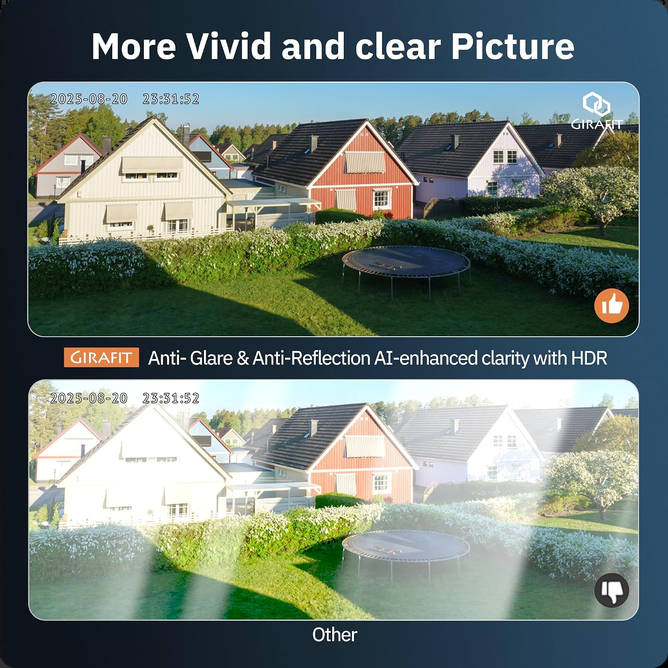

Exemplo 2 — Fundo complexo (moldura, marca d'água, barra de tarefas):


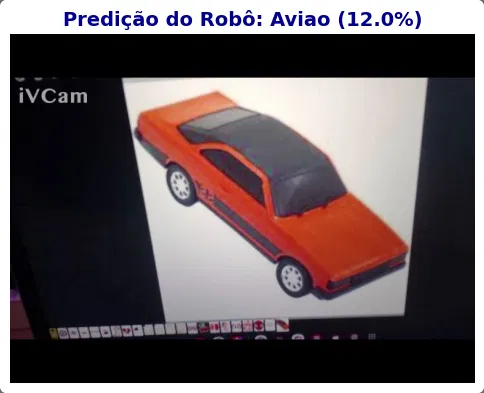

Exemplo 3 — Mudança de escala (objeto pequeno no quadro):


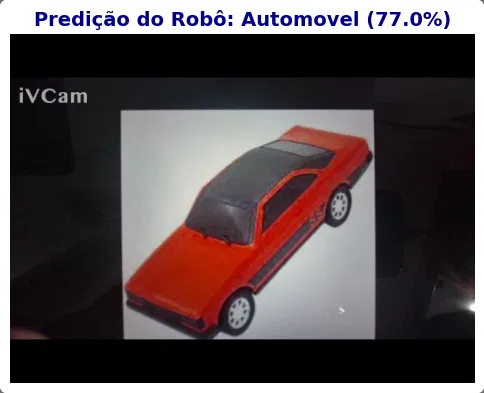

In [24]:
from IPython.display import Image, display

print("Exemplo 1 — Iluminação ambiente (reflexo de tela):")
display(Image(filename='captura1.png', width=400))

print("Exemplo 2 — Fundo complexo (moldura, marca d'água, barra de tarefas):")
display(Image(filename='captura2.png', width=400))

print("Exemplo 3 — Mudança de escala (objeto pequeno no quadro):")
display(Image(filename='captura3.png', width=400))

  Um exemplo concreto disso, dentre as próprias capturas feitas neste laboratório, foi a imagem em que aparece um brilho forte na parte inferior da tela sendo filmada, criando uma área de reflexo que não existe nas fotografias controladas do dataset original.

  O segundo fator é o fundo complexo presente nas capturas ao vivo. Nas imagens do CIFAR-10, o fundo é simples e não compete visualmente com o objeto principal. Já nas capturas feitas com a webcam, o fundo incluiu elementos como a moldura preta do monitor sendo filmado, o texto "iVCam" sobreposto no canto da imagem e, em um dos testes, até a barra de tarefas do computador aparecendo na parte inferior do quadro. Esse ruído visual adicional atrapalha a extração das características relevantes do objeto pela rede, que nunca foi treinada para ignorar esse tipo de elemento.

  O terceiro fator é a mudança de escala do objeto dentro do quadro capturado. No CIFAR-10, o objeto ocupa quase toda a extensão da imagem, mas nas capturas realizadas com a webcam o objeto de interesse aparece relativamente pequeno em relação ao restante do quadro, cercado por uma área escura considerável. Isso ficou evidente nas duas primeiras capturas feitas neste laboratório, nas quais o carro ocupava apenas uma fração pequena e central da imagem. Quando essa imagem é redimensionada para 32x32 pixels durante o pré-processamento, o objeto perde grande parte de seus detalhes, resultando em uma representação borrada que dificulta significativamente a tarefa de classificação, o que se refletiu nas confianças de previsão próximas de 11 a 12 por cento observadas nesses testes, contra os 77 por cento obtidos na captura em que o objeto estava mais próximo, melhor enquadrado e mais centralizado, condição que se aproxima mais das características do conjunto de treinamento original.

## Parte 9:  🚀 Desafio Prático

Adicionar uma célula ao final do notebook e implementarem as seguintes melhorias:

1. **Aumento de Dados (*Data Augmentation*):**
Adicionar camadas de transformação aleatória na entrada do modelo Keras para tornar o robô mais robusto a variações de orientação e iluminação na câmera:

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

2. **Filtro de Rejeição por Confiança (Safety Threshold):**
Modificar o código da webcam para que o robô emita um aviso de *"Objeto Não Identificado / Incerto"* caso a confiança da maior probabilidade seja inferior a **60%** ($\text{Confiança} < 0.60$), prevenindo ações desastrosas do manipulador mecânico.

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3728 - loss: 1.7229 - val_accuracy: 0.4964 - val_loss: 1.3928
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4706 - loss: 1.4689 - val_accuracy: 0.5575 - val_loss: 1.2242
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5095 - loss: 1.3723 - val_accuracy: 0.5660 - val_loss: 1.2231
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5303 - loss: 1.3141 - val_accuracy: 0.5938 - val_loss: 1.1425
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5499 - loss: 1.2629 - val_accuracy: 0.5903 - val_loss: 1.1842
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5619 - loss: 1.2382 - val_accuracy: 0.6019 - val_loss: 1.1759
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5746 - loss: 1.2058 - val_accuracy: 0.6053 - val_loss: 1.1186
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5801 - loss: 1.1818 - val_accuracy: 0

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


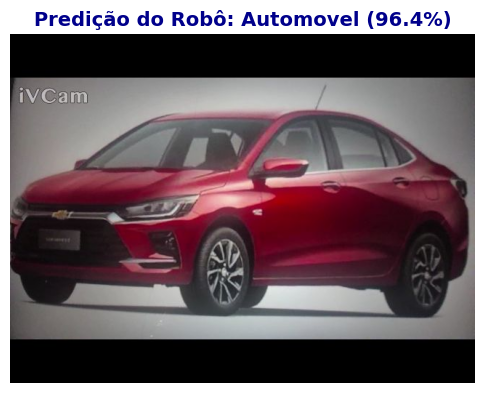

In [28]:
## 9. Desafio Prático - Data Augmentation + Safety Threshold

import time
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import io
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARTE A - Aumento de Dados (Data Augmentation)
# =========================================================

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

def build_robot_cnn_augmented(input_shape=(32, 32, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)

    # Aumento de dados só é aplicado durante o treinamento
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv_1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool_1')(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool_2')(x)

    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(128, activation='relu', name='fc_1')(x)
    x = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return tf.keras.Model(inputs, outputs)

model_augmented = build_robot_cnn_augmented()
model_augmented.summary()

model_augmented.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

history_augmented = model_augmented.fit(x_train, y_train,
                                          epochs=10,
                                          validation_data=(x_test, y_test),
                                          batch_size=64)

# =========================================================
# PARTE B - Captura via Webcam com Filtro de Confiança
# =========================================================

CONFIDENCE_THRESHOLD = 0.60

def capture_webcam_frame():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const capture = document.createElement('button');

      capture.textContent = '📸 Capturar Frame e Classificar';
      capture.style.padding = '10px 20px';
      capture.style.fontSize = '16px';
      capture.style.backgroundColor = '#008CBA';
      capture.style.color = 'white';
      capture.style.border = 'none';
      capture.style.borderRadius = '5px';
      capture.style.cursor = 'pointer';
      capture.style.marginTop = '10px';

      video.style.display = 'block';
      video.style.borderRadius = '8px';

      let stream;
      try {
        stream = await navigator.mediaDevices.getUserMedia({video: true});
      } catch (err) {
        throw new Error("Permissão da câmera negada. Por favor, permita o acesso na barra do navegador.");
      }

      document.body.appendChild(div);
      div.appendChild(video);
      div.appendChild(capture);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', 0.8);
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')

    binary = b64decode(data.split(',')[1])
    img_pil = Image.open(io.BytesIO(binary))
    img_np = np.array(img_pil)
    return img_np

try:
    print("Aguardando interação com a câmera...")
    raw_frame = capture_webcam_frame()

    # Pré-processamento
    img_resized = cv2.resize(raw_frame, (32, 32))
    img_normalized = img_resized.astype('float32') / 255.0
    img_tensor = np.expand_dims(img_normalized, axis=0)

    # Inferência com o modelo treinado com data augmentation
    prediction = model_augmented.predict(img_tensor)
    class_idx = np.argmax(prediction[0])
    confidence = prediction[0][class_idx]

    # Filtro de segurança por confiança
    if confidence < CONFIDENCE_THRESHOLD:
        titulo = f"⚠️ Objeto Não Identificado / Incerto ({confidence*100:.1f}%)"
        cor_titulo = 'darkred'
    else:
        titulo = f"Predição do Robô: {class_names[class_idx]} ({confidence*100:.1f}%)"
        cor_titulo = 'darkblue'

    # Exibição
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_frame)
    plt.title(titulo, fontsize=14, fontweight='bold', color=cor_titulo)
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Erro ao acessar a câmera: {e}")

- - -

### 10) Relatório: Elaborar o relatório em formato **jupyter** e hospedar no github, conforme instruções em aulas anteriores.

Além de texto e códigos, o relatório deve conter as imagens e os videos.

O relatório deverá conter pelo menos os seguintes tipos de Seções:
- Título do relatório
- Nome completo dos autores do relatório
- Data de realização dos experimentos
- Data de publicação do relatório
- Introdução – apresentando o que será descrito e relatado
- Fundamentação Teórica - introdução ao assunto a ser estudado nos experimentos
- Procedimentos experimentais – explicando como realizar e executar as atividades
- Análise e discussão dos estudos realizados
- Conclusões
- Referências consultadas e indicadas.

Cada relatório deverá ser colocado numa pasta separada, junto com os arquivos pertinentes.
A página HTML da equipe deverá conter um índice das aulas de laboratório, com um link para cada relatório.





### ATENÇÃO ESPECIAL:

1- O Cnpq lançou uma portaria 2664/2026, que discute de forma mais ampla a integridade da pesquisa científica no CNPq, e possui algumas diretrizes (replicada abaixo) para o uso da IA.

Link: http://memoria2.cnpq.br/web/guest/view/-/journal_content/56_INSTANCE_0oED/10157/23142775
"
c) declarar o uso de ferramentas de Inteligência Artificial Generativa - IAG, de qualquer espécie e em qualquer fase do desenvolvimento da pesquisa (concepção, redação, análise de dados, submissão) especificando nos respectivos textos e exposições eletrônicas, a ferramenta utilizada e a finalidade;

d) é vedada a submissão de conteúdo gerado por IAG como se fosse de autoria humana, sendo os autores integralmente responsáveis pelo conteúdo final, inclusive por eventuais plágios ou imprecisões geradas pela IAG;

e) é vedada a inserção de projetos de pesquisa de terceiros em ferramentas de IAG para elaboração de pareceres científicos;

f) responsabilizar-se integralmente pelo conteúdo final da pesquisa, inclusive por eventuais plágios ou imprecisões geradas pela IAG;
"

Portanto, se for seu caso, faça tais menções de IAG no seu relatório de forma rigorosa.

- - - -